In [10]:
import sys
from pathlib import Path

parent_folder = Path.cwd().parent
if str(parent_folder) not in sys.path:
    sys.path.append(str(parent_folder))
    
import warnings
warnings.filterwarnings('ignore')
import numpy as np

import simulation_functional as sim
import xobjects as xo
import copy
import matplotlib.pyplot as plt

Converting sequence "synchrotron":   0%|          | 0/1990 [00:00<?, ?it/s]

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


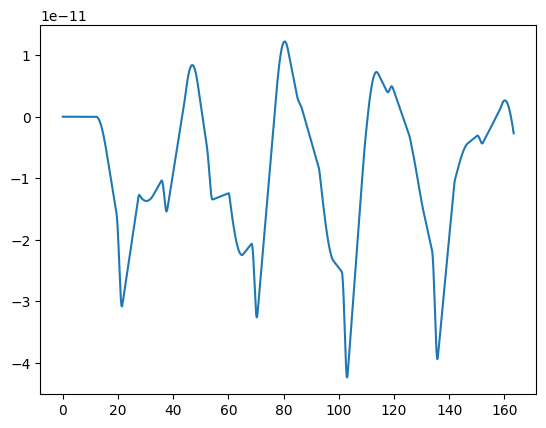

In [16]:
line = sim.build_line(folder=Path('../Lattice_Files/02_Aperture_Lattice_res/'))

tw = line.twiss(method='4d', freeze_longitudinal=True)
plt.plot(tw.s, tw.x)
plt.show()
length=line.get_length()

Converting sequence "synchrotron":   0%|          | 0/1990 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/3980 [00:00<?, ?it/s]

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
x: -0.006057289561404964
y: 4.028987280573777e-27
px: 0.0025276132955217414
py: 7.897109053741705e-28


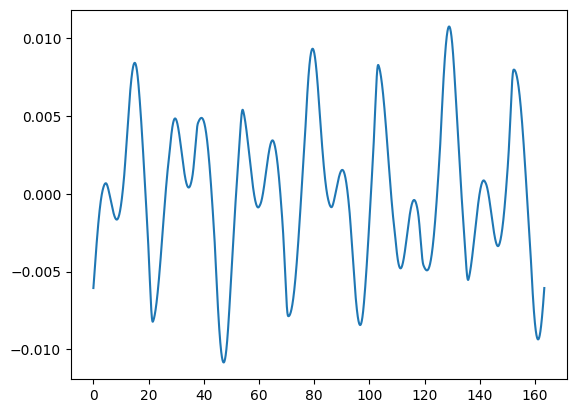

In [22]:
line = sim.build_line(folder=Path('../Lattice_Files/02_Aperture_Lattice_res/'))

s_list = np.linspace(0, line.get_length(), 13*1024, endpoint=False)
#twiss_at_kicks = line.twiss(at_s=s_list, method='4d', freeze_longitudinal=True)

#phi_x = twiss_at_kicks.mux * 2 * np.pi 
#beta_x = twiss_at_kicks.betx

strength_list = 1e-5 * np.sin(13 * 2*np.pi*s_list/length)# / np.sqrt(beta_x)

line = sim.add_dipole(line, strength=strength_list, s=s_list, mode='normal')

tw = line.twiss(method='4d', freeze_longitudinal=True)
#particles = line.build_particles(
#    x=tw.x[0],
#    y=tw.y[0],
#    px=tw.px[0],
#    py=tw.py[0],
#    method='4d', 
#    freeze_longitudinal=True)

print(f'x: {tw.x[0]}')
print(f'y: {tw.y[0]}')
print(f'px: {tw.px[0]}')
print(f'py: {tw.py[0]}')

plt.plot(tw.s, tw.x)


In [3]:
gemitt = 60e-6
n_turns = 1

line, beam_df, aper_df = sim.add_spacecharge(line, beam_intensity=1e13,
                                                 n_interactions=100, 
                                                 gemitt=gemitt, indirect=True)
    
line.build_tracker(_context=xo.ContextCpu(omp_num_threads=1))
line.track(particles, num_turns=n_turns, time=True)

sigma_x = np.sqrt(gemitt*tw.betx[0])
sigma_y = np.sqrt(gemitt*tw.bety[0])
sigma_px = np.sqrt(gemitt*tw.gamx[0])
sigma_py = np.sqrt(gemitt*tw.gamy[0])

print(f'x: {abs(particles.x-tw.x[0])/sigma_x}')
print(f'y: {abs(particles.y-tw.y[0])/sigma_y}')
print(f'px: {abs(particles.px-tw.px[0])/sigma_px}')
print(f'py: {abs(particles.py-tw.py[0])/sigma_py}')

Slicing line:   0%|          | 0/4126 [00:00<?, ?it/s]

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
x: [0.00404779]
y: [8.20974058e-18]
px: [0.00102773]
py: [9.59614639e-18]
